In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, mutual_info_regression


from sklearn.feature_selection import SelectFromModel


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import optuna


In [3]:
df = pd.read_csv("otto-group-product-classification-challenge/train.csv")
df.head()

,id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,target
0,1,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,Class_1
1,2,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
2,3,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
3,4,1,0,0,1,6,1,5,0,0,...,0,1,2,0,0,0,0,0,0,Class_1
4,5,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,Class_1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61878 entries, 0 to 61877
Data columns (total 95 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       61878 non-null  int64 
 1   feat_1   61878 non-null  int64 
 2   feat_2   61878 non-null  int64 
 3   feat_3   61878 non-null  int64 
 4   feat_4   61878 non-null  int64 
 5   feat_5   61878 non-null  int64 
 6   feat_6   61878 non-null  int64 
 7   feat_7   61878 non-null  int64 
 8   feat_8   61878 non-null  int64 
 9   feat_9   61878 non-null  int64 
 10  feat_10  61878 non-null  int64 
 11  feat_11  61878 non-null  int64 
 12  feat_12  61878 non-null  int64 
 13  feat_13  61878 non-null  int64 
 14  feat_14  61878 non-null  int64 
 15  feat_15  61878 non-null  int64 
 16  feat_16  61878 non-null  int64 
 17  feat_17  61878 non-null  int64 
 18  feat_18  61878 non-null  int64 
 19  feat_19  61878 non-null  int64 
 20  feat_20  61878 non-null  int64 
 21  feat_21  61878 non-null  int64 
 22

In [5]:
df.dtypes.value_counts()

int64     94
object     1
Name: count, dtype: int64

In [6]:
df.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['id', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6',
       'feat_7', 'feat_8', 'feat_9', 'feat_10', 'feat_11', 'feat_12',
       'feat_13', 'feat_14', 'feat_15', 'feat_16', 'feat_17', 'feat_18',
       'feat_19', 'feat_20', 'feat_21', 'feat_22', 'feat_23', 'feat_24',
       'feat_25', 'feat_26', 'feat_27', 'feat_28', 'feat_29', 'feat_30',
       'feat_31', 'feat_32', 'feat_33', 'feat_34', 'feat_35', 'feat_36',
       'feat_37', 'feat_38', 'feat_39', 'feat_40', 'feat_41', 'feat_42',
       'feat_43', 'feat_44', 'feat_45', 'feat_46', 'feat_47', 'feat_48',
       'feat_49', 'feat_50', 'feat_51', 'feat_52', 'feat_53', 'feat_54',
       'feat_55', 'feat_56', 'feat_57', 'feat_58', 'feat_59', 'feat_60',
       'feat_61', 'feat_62', 'feat_63', 'feat_64', 'feat_65', 'feat_66',
       'feat_67', 'feat_68', 'feat_69', 'feat_70', 'feat_71', 'feat_72',
       'feat_73', 'feat_74', 'feat_75', 'feat_76', 'feat_77', 'feat_78',
       'feat_79'

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
target_col = "target"
y = df[target_col]
X = df.drop(columns=[target_col, "id"])

In [10]:
y.nunique()

9

In [11]:
classes = sorted(y.unique())
print(classes)

['Class_1', 'Class_2', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7', 'Class_8', 'Class_9']


In [12]:
y.value_counts().sort_values()


target
Class_1     1929
Class_4     2691
Class_5     2739
Class_7     2839
Class_9     4955
Class_3     8004
Class_8     8464
Class_6    14135
Class_2    16122
Name: count, dtype: int64

In [13]:
y.value_counts(normalize=True).mul(100).round(2)

target
Class_2    26.05
Class_6    22.84
Class_8    13.68
Class_3    12.94
Class_9     8.01
Class_7     4.59
Class_5     4.43
Class_4     4.35
Class_1     3.12
Name: proportion, dtype: float64

In [14]:
y.describe()

count       61878
unique          9
top       Class_2
freq        16122
Name: target, dtype: object

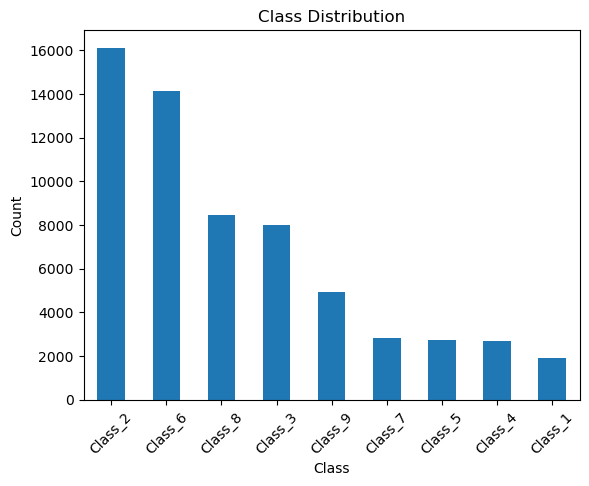

In [15]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [16]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [17]:
outlier_counts = ((X < lower) |
                  (X > upper)).sum()

print(outlier_counts.sort_values(ascending=False))

feat_60    15420
feat_35    13828
feat_89    13630
feat_92    13592
feat_4     13430
           ...  
feat_81     3183
feat_5      2971
feat_51     1719
feat_84     1423
feat_6      1168
Length: 93, dtype: int64


In [18]:

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.90

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > threshold)
]

print("Number of features before:", X.shape[1])
print("Number of features to drop:", len(to_drop))
print("Dropped features:", to_drop)

Number of features before: 93
Number of features to drop: 0
Dropped features: []


In [19]:


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_valid.shape)
print(y_valid.shape)



(49502, 93)
(12376, 93)
(12376,)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_linear = scaler.fit_transform(X_train)
X_valid_linear = scaler.transform(X_valid)

In [21]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{'Class_1': np.float64(3.564628789515374), 'Class_2': np.float64(0.42643993039403183), 'Class_3': np.float64(0.8590070626615997), 'Class_4': np.float64(2.5546782267636887), 'Class_5': np.float64(2.5103707084537756), 'Class_6': np.float64(0.48640097472782295), 'Class_7': np.float64(2.421938451000538), 'Class_8': np.float64(0.81232051723855), 'Class_9': np.float64(1.387543446574728)}


In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=2000,
    class_weight=class_weights,
    random_state=42
)

logreg.fit(X_train_linear, y_train)

y_pred_lr = logreg.predict(X_valid_linear)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_valid, y_pred_lr))
print("Macro F1:", f1_score(y_valid, y_pred_lr, average="macro"))
print("Weighted F1:", f1_score(y_valid, y_pred_lr, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_valid, y_pred_lr))

===== Logistic Regression =====
Accuracy: 0.7177601809954751
Macro F1: 0.6869329588270945
Weighted F1: 0.731699233147185

Classification Report:
              precision    recall  f1-score   support

     Class_1       0.34      0.70      0.46       386
     Class_2       0.77      0.59      0.67      3224
     Class_3       0.50      0.52      0.51      1601
     Class_4       0.32      0.65      0.43       538
     Class_5       0.90      0.98      0.94       548
     Class_6       0.97      0.85      0.90      2827
     Class_7       0.54      0.72      0.62       568
     Class_8       0.91      0.84      0.87      1693
     Class_9       0.81      0.78      0.79       991

    accuracy                           0.72     12376
   macro avg       0.67      0.74      0.69     12376
weighted avg       0.76      0.72      0.73     12376



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train, y_train)

y_pred_rf_selector = rf_selector.predict(X_valid)



In [24]:
print("===== rf_selector =====")
print("Accuracy:", accuracy_score(y_valid, y_pred_rf_selector))
print("Macro F1:", f1_score(y_valid, y_pred_rf_selector, average="macro"))
print("Weighted F1:", f1_score(y_valid, y_pred_rf_selector, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_valid, y_pred_rf_selector))

===== rf_selector =====
Accuracy: 0.8081771170006464
Macro F1: 0.7608809715999943
Weighted F1: 0.7985095765472681

Classification Report:
              precision    recall  f1-score   support

     Class_1       0.76      0.48      0.59       386
     Class_2       0.70      0.89      0.79      3224
     Class_3       0.65      0.45      0.53      1601
     Class_4       0.87      0.44      0.58       538
     Class_5       0.98      0.97      0.97       548
     Class_6       0.93      0.94      0.93      2827
     Class_7       0.76      0.61      0.68       568
     Class_8       0.89      0.94      0.91      1693
     Class_9       0.85      0.88      0.87       991

    accuracy                           0.81     12376
   macro avg       0.82      0.73      0.76     12376
weighted avg       0.81      0.81      0.80     12376



In [25]:
importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)


Feature Importance:
feat_34    0.085872
feat_67    0.030670
feat_11    0.028951
feat_25    0.027941
feat_14    0.026509
             ...   
feat_84    0.001731
feat_31    0.001596
feat_82    0.001465
feat_51    0.001119
feat_6     0.000946
Length: 93, dtype: float64


In [26]:
selector = SelectFromModel(
    rf_selector,
    threshold="median",
    prefit=True
)

selected_mask = selector.get_support()

selected_features = X_train.columns[selected_mask]


In [27]:
X_train_selected = X_train[selected_features]
X_valid_selected = X_valid[selected_features]


print("\n========== Feature Selection ==========")
print("Before:", X_train.shape[1])
print("After :", X_train_selected.shape[1])

print("\nSelected features:")
print(list(selected_features))


========== Feature Selection ==========
Before: 93
After : 47

Selected features:
['feat_1', 'feat_3', 'feat_8', 'feat_9', 'feat_11', 'feat_14', 'feat_15', 'feat_16', 'feat_17', 'feat_24', 'feat_25', 'feat_26', 'feat_32', 'feat_33', 'feat_34', 'feat_36', 'feat_38', 'feat_39', 'feat_40', 'feat_41', 'feat_42', 'feat_43', 'feat_47', 'feat_48', 'feat_50', 'feat_53', 'feat_54', 'feat_56', 'feat_59', 'feat_60', 'feat_62', 'feat_64', 'feat_66', 'feat_67', 'feat_68', 'feat_69', 'feat_70', 'feat_71', 'feat_72', 'feat_75', 'feat_76', 'feat_78', 'feat_85', 'feat_86', 'feat_88', 'feat_90', 'feat_92']


In [28]:
print(
    importance.head()
)

feat_34    0.085872
feat_67    0.030670
feat_11    0.028951
feat_25    0.027941
feat_14    0.026509
dtype: float64


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_selected, y_train)

y_pred_rf = rf.predict(X_valid_selected)



In [30]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_valid_xgb = label_encoder.transform(y_valid)


In [31]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=9,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_selected, y_train_xgb)

y_pred_xgb = xgb.predict(X_valid_selected)



In [32]:
from catboost import CatBoostClassifier

cb = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=False,
    thread_count=-1,
    auto_class_weights="Balanced"
)

cb.fit(
    X_train_selected,
    y_train,
    eval_set=(X_valid_selected, y_valid),
    early_stopping_rounds=50
)

y_pred_cb = cb.predict(X_valid_selected).ravel()



In [33]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "Accuracy": [
        accuracy_score(y_valid, y_pred_rf),
        accuracy_score(y_valid_xgb, y_pred_xgb),
        accuracy_score(y_valid, y_pred_cb)
    ],
    "Macro F1": [
        f1_score(y_valid, y_pred_rf, average="macro"),
        f1_score(y_valid_xgb, y_pred_xgb, average="macro"),
        f1_score(y_valid, y_pred_cb, average="macro")
    ],
    "Weighted F1": [
        f1_score(y_valid, y_pred_rf, average="weighted"),
        f1_score(y_valid_xgb, y_pred_xgb, average="weighted"),
        f1_score(y_valid, y_pred_cb, average="weighted")
    ]
})

results = results.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

print(results)

           Model  Accuracy  Macro F1  Weighted F1
0  Random Forest  0.801471  0.751744     0.791295
1        XGBoost  0.795006  0.744067     0.787490
2       CatBoost  0.733920  0.700334     0.747446
